## License

This notebook is a conversion of a Sentinel Hub evalscript and is licensed under **CC-BY-SA-4.0.**  

Original evalscript: https://custom-scripts.sentinel-hub.com/custom-scripts/sentinel-2/snow_classifier/
Source: Sentinel Hub Custom Scripts (CC-BY-SA-4.0)  
Conversion: Development Seed (openEO-UDP project)

# Snow Classifier with OpenEO Processes

This notebook demonstrates how to detect snow using the Normalized Difference Snow Index (NDSI) and the Normalized Difference Vegetation Index (NDVI), which are defined as:

NDSI is to detect snow
\begin{equation*}
    NDSI = \frac{B03 - B11}{B03 + B11}
\end{equation*}

NDVI as an additional constraint
\begin{equation*}
    NDVI = \frac{B08 - B04}{B08 + B04}
\end{equation*}

Where: 
- B03 (559.8 nm): Green
- B04 (664.6 nm): Red
- B08 (832.8 nm): NIR
- B11 (1613.7 nm): SWIR

## Overview

In this notebook, we will:
1. Connect to an OpenEO backend service
2. Define an area of interest containing terrestrial land
3. Load Sentinel-2-L2A imagery for a specific date
4. Calculate NDSI and NDVI to detect snow
    - Snow is indicated by NDSI >= 0.4
    - NDSI values even lower than 0.4 could imply snow, given that the pixel's NDVI is close enough to 0.1
    - In either case, the pixel must also be bright in the green band (03 > 0.3)
5. Determine the color map for snow and non-snow areas
    - Snow pixels are shown in a light beige color
    - Non-snow pixels are shown as a brightened true-color RGB composite

## Import Required Libraries

We begin by importing the necessary Python libraries for data processing and visualization.

In [1]:
import openeo
import matplotlib.pyplot as plt
from PIL import Image
from openeo.processes import array_create, if_, absolute, and_

## Connect to OpenEO Backend

Connect to the OpenEO backend and authenticate using OpenID Connect.

In [2]:
connection = openeo.connect(
    url="https://openeo.dataspace.copernicus.eu/"
).authenticate_oidc()

Authenticated using refresh token.


## Define Area of Interest

Define the spatial extent for our analysis. This example uses coordinates Las Palmas de Grand Canaria, Spain. You can modify these coordinates to analyze any terrestrial land where snow is prevalent.

In [3]:
spatial_extent = {"west" : 13.40, "south" :46.32, "east" : 13.54, "north" : 46.39}

## Load Sentinel-2 Data

Load Sentinel-2 L2A (bottom-of-atmosphere reflectance) data.

In [4]:
s2cube = connection.load_collection(
    "SENTINEL2_L2A",
    spatial_extent=spatial_extent,
    temporal_extent=["2019-10-26", "2019-10-30"], # 
    bands=[
        "B02",
        "B03",
        "B11",
        "B08",
        "B04"
    ],
)

# Filter for a specific date
s2cube = s2cube.reduce_dimension(dimension="t", reducer="first")

## Define the process to classify snow

In [5]:
def snow_classifier(data):
    B02, B03, B11, B08, B04 = (
        data[0],
        data[1],
        data[2],
        data[3],
        data[4]
    )

    # Scale to reflectance
    B02 = B02 / 10000
    B03 = B03 / 10000
    B11 = B11 / 10000
    B08 = B08 / 10000
    B04 = B04 / 10000

    # Brightness for true-color composite
    gain = 2.5

    # Indexes
    NDSI = (B03 - B11) / (B03 + B11)
    NDVI = (B08 - B04) / (B08 + B04)

    is_snow = if_(
        NDSI >= 0.4,
        1,
        if_(
            absolute(NDVI - 0.1) <= 0.025,
            1,
            0
        )
    )

    mask_condition = and_(is_snow, B03 > 0.3)

    red = if_(
        mask_condition,
        1.0,
        B04 * gain
    )

    green = if_(
        mask_condition,
        0.8,
        B03 * gain
    )

    blue = if_(
        mask_condition,
        0.4,
        B02 * gain
    )

    return array_create([red, green, blue])

In [6]:
snow_image = s2cube.apply_dimension(
    dimension="bands",
    process=snow_classifier
)

snow_image = snow_image.linear_scale_range(input_min=0, input_max=1, output_min=0, output_max=255)

snow_image = snow_image.save_result("PNG")

In [7]:
snow_image.download("snow_classifier.png")

## Visualize the Result

Display the generated snow map with the color-coded legend.

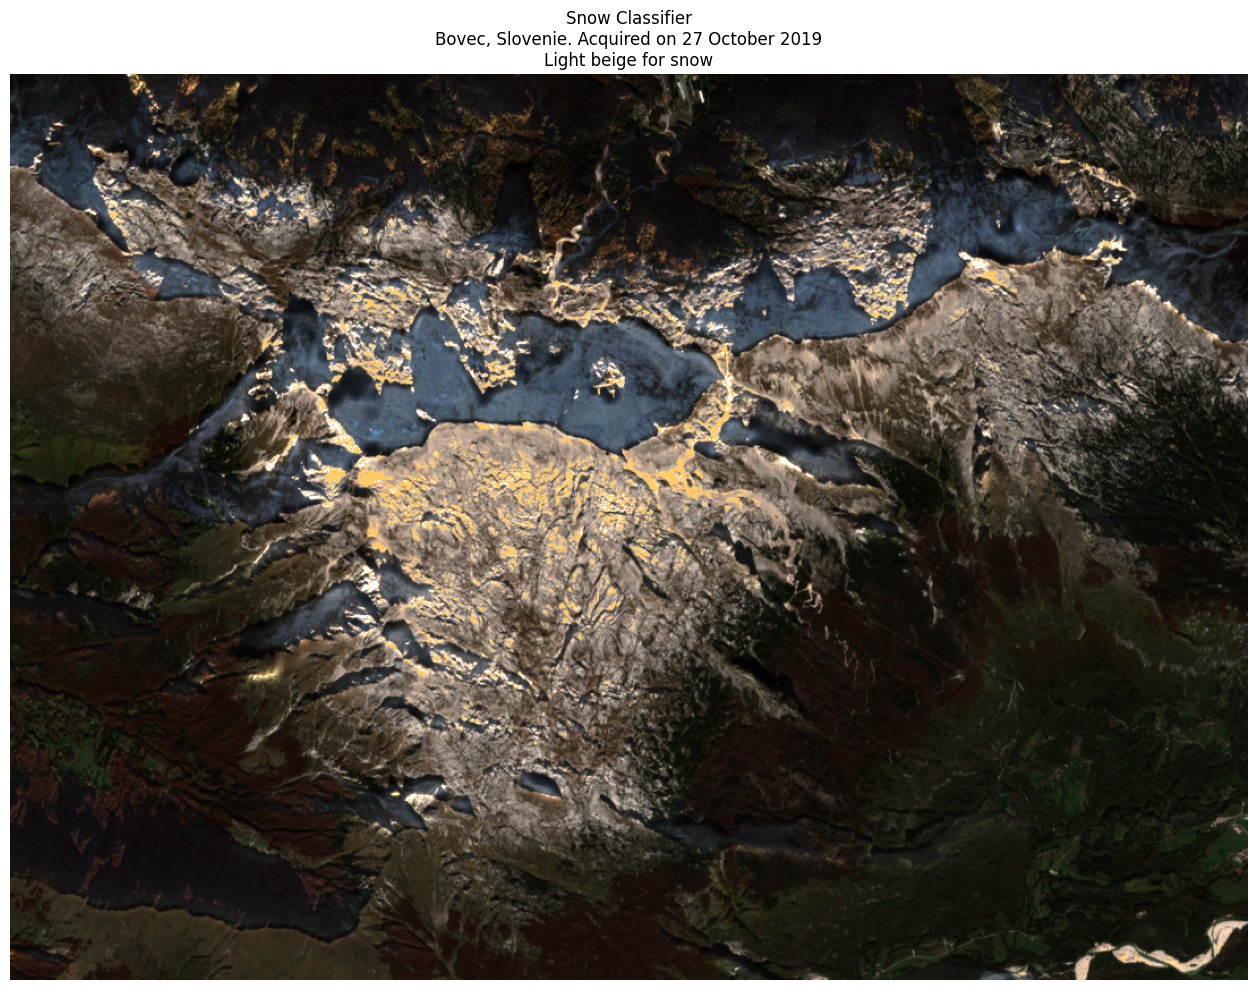

In [8]:
# Load and display the image
img = Image.open("snow_classifier.png")

fig, ax = plt.subplots(figsize=(14, 10), dpi=100)
ax.imshow(img)
ax.set_title(
    "Snow Classifier\n"
    "Bovec, Slovenie. Acquired on 27 October 2019\n"
    "Light beige for snow",
    fontsize=12,
)
ax.axis("off")
plt.tight_layout()
plt.show()

## Citation
Hagolle, O., Huc, M., Desjardins, C., Auer, S., Richter, R. (2017). MAJA Algorithm Theoretical Basis Document (Version 1.0). Zenodo. https://doi.org/10.5281/zenodo.1209633

Dietz, A.J., Kuenzer, C., Gessner, U., Dech, S. (2012): Remote Sensing of Snow – A Review of Available Methods. International Journal of Remote Sensing. 33(13), 4094-4134. https://dx.doi.org/10.1080/01431161.2011.640964

## Attribution

This openEO User-Defined Process is a conversion of the original Sentinel Hub evalscript:

**Original Script:** [Snow Classifier](https://custom-scripts.sentinel-hub.com/custom-scripts/sentinel-2/snow_classifier/)

**Author:** -

**Source Repository:** [Sentinel Hub Custom Scripts](https://github.com/sentinel-hub/custom-scripts)

This conversion maintains the scientific methodology and visualization approach of the original evalscript while adapting it to the openEO process graph framework for interoperability across openEO-compliant backends.

## Conclusion

This notebook demonstrates the implementation of Snow Classifier algorithm for mapping snow using openEO and Sentinel-2 imagery. The notebook succesfully:

- Identifies snowing areas using multiple spectral indices
- Produces color-mapped visualizations